In [1]:
import pandas as pd
import matplotlib.pyplot as plt


In [2]:
ruta = "noticias_energia_CO_limpio_v1.csv"

df = pd.read_csv(ruta)

print("Dimensiones del dataset:", df.shape)
df.head()


Dimensiones del dataset: (7513, 9)


,Query,Titulo,Fuente,Fecha,url,Hora,Año,Mes,Dia
0,energía Colombia,Llega el agua para La Guajira a traves de exca...,Minvivienda,2015-01-17,https://news.google.com/rss/articles/CBMiwAFBV...,08:00:00,2015,Enero,Sábado
1,energía Colombia,Reforma tributaria - Ley 1739 de 2014 - Hollan...,Holland & Knight,2015-01-27,https://news.google.com/rss/articles/CBMilgFBV...,08:00:00,2015,Enero,Martes
2,energía Colombia,"""Hidrosogamoso nos aleja de un racionamiento d...",Vanguardia,2015-01-15,https://news.google.com/rss/articles/CBMixAFBV...,08:00:00,2015,Enero,Jueves
3,energía Colombia,La colombiana Edemsa ganó contrato de energía ...,Semana.com,2015-01-25,https://news.google.com/rss/articles/CBMisAFBV...,08:00:00,2015,Enero,Domingo
4,energía Colombia,"A falta de melaza para el ganado, ¿bueno es el...",CONtexto Ganadero,2015-01-19,https://news.google.com/rss/articles/CBMirAFBV...,08:00:00,2015,Enero,Lunes


In [13]:
orden_meses = [
    'Enero', 'Febrero', 'Marzo', 'Abril', 'Mayo', 'Junio',
    'Julio', 'Agosto', 'Septiembre', 'Octubre', 'Noviembre', 'Diciembre'
]

df['Mes'] = pd.Categorical(df['Mes'], categories=orden_meses, ordered=True)
df['Fecha'] = pd.to_datetime(df['Fecha'], errors='coerce')
df.dtypes

Query             object
Titulo            object
Fuente            object
Fecha     datetime64[ns]
url               object
Hora              object
Año                int64
Mes             category
Dia               object
dtype: object

In [9]:
tabla_anio_mes = (
    df
    .groupby(['Año', 'Mes'])
    .size()
    .reset_index(name='Cantidad_Noticias')
)

tabla_anio_mes.head(12)


C:\Users\Jhon Fernando Tascón\AppData\Local\Temp\ipykernel_3756\527515809.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(['Año', 'Mes'])


,Año,Mes,Cantidad_Noticias
0,2015,Enero,41
1,2015,Febrero,33
2,2015,Marzo,43
3,2015,Abril,30
4,2015,Mayo,28
5,2015,Junio,35
6,2015,Julio,33
7,2015,Agosto,36
8,2015,Septiembre,26
9,2015,Octubre,45


In [5]:
tabla_total_anual = (
    df
    .groupby('Año')
    .size()
    .reset_index(name='Total_Noticias_Año')
)

tabla_total_anual


,Año,Total_Noticias_Año
0,2015,420
1,2016,430
2,2017,464
3,2018,418
4,2019,506
5,2020,491
6,2021,496
7,2022,700
8,2023,1059
9,2024,1173


In [10]:
tabla_anio_mes_fuente = (
    df
    .groupby(['Año', 'Mes', 'Fuente'])
    .size()
    .reset_index(name='Cantidad_Noticias')
)

tabla_anio_mes_fuente.head(12)


C:\Users\Jhon Fernando Tascón\AppData\Local\Temp\ipykernel_3756\2428106180.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(['Año', 'Mes', 'Fuente'])


,Año,Mes,Fuente,Cantidad_Noticias
0,2015,Enero,- CIPER Chile,0
1,2015,Enero,.: El Sol de Margarita :.,0
2,2015,Enero,180.com.uy,0
3,2015,Enero,20Minutos,0
4,2015,Enero,350.org,0
5,2015,Enero,360 Radio,0
6,2015,Enero,A La Luz Pública,0
7,2015,Enero,ABC,0
8,2015,Enero,ACI Prensa,0
9,2015,Enero,ACR Latinoamérica,0


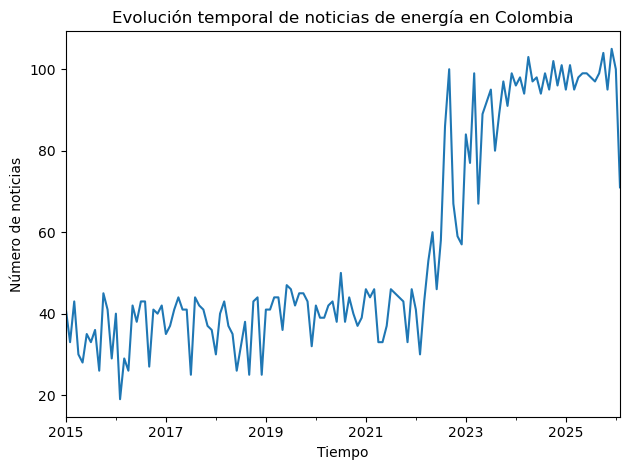

In [14]:
import matplotlib.pyplot as plt

serie_tiempo = (
    df
    .groupby(df['Fecha'].dt.to_period('M'))
    .size()
)

plt.figure()
serie_tiempo.plot()
plt.title("Evolución temporal de noticias de energía en Colombia")
plt.xlabel("Tiempo")
plt.ylabel("Número de noticias")
plt.tight_layout()
plt.show()


In [15]:
top_fuentes = df['Fuente'].value_counts().head(5).index.tolist()
top_fuentes


['Valora Analitik',
 'Infobae',
 'LaRepublica.co',
 'Portafolio.co',
 'Ministerio de Minas y Energía']

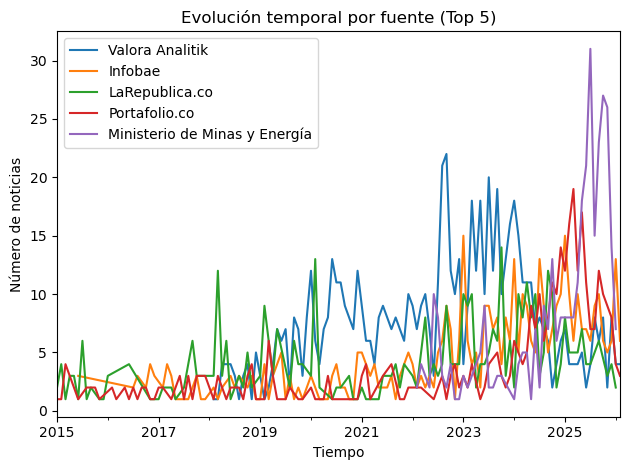

In [16]:
plt.figure()

for fuente in top_fuentes:
    serie_fuente = (
        df[df['Fuente'] == fuente]
        .groupby(df['Fecha'].dt.to_period('M'))
        .size()
    )
    serie_fuente.plot(label=fuente)

plt.title("Evolución temporal por fuente (Top 5)")
plt.xlabel("Tiempo")
plt.ylabel("Número de noticias")
plt.legend()
plt.tight_layout()
plt.show()


In [18]:
tabla_por_fuente = (
    df
    .groupby('Fuente')
    .size()
    .reset_index(name='Total_Noticias')
    .sort_values(by='Total_Noticias', ascending=False)
)

tabla_por_fuente


,Fuente,Total_Noticias
534,Valora Analitik,745
286,Infobae,485
324,LaRepublica.co,465
415,Portafolio.co,413
357,Ministerio de Minas y Energía,353
...,...,...
648,subrayado.com.uy,1
7,ABC,1
6,A La Luz Pública,1
4,350.org,1
